## Session-Level Overview
Quick checks on session types and message-turn distributions.


In [1]:
import pandas as pd

session_mapping = pd.read_json("../data/core/session_mapping.json")
annotated_misalignments = pd.read_json("../data/core/annotated_misalignments.json")

In [2]:
session_mapping[["session_type", "agent"]].value_counts()

session_type  agent      
IDE           Unknown        8631
CLI           Claude Code    6648
IDE           Cursor IDE     3234
CLI           OpenCode        624
              Codex           517
              Unknown         482
IDE           Copilot IDE     366
CLI           Gemini CLI       39
              Cursor CLI       32
              Copilot CLI       1
Name: count, dtype: int64

In [3]:
df = session_mapping.copy()
df = df[df["session_type"].isin(["IDE", "CLI"])]

quantiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

for metric in ["user_turns", "agent_turns"]:
    summary = (
        df[df[metric] > 0]
        .groupby("session_type")[metric]
        .agg(n="size", mean="mean", median="median", min="min", max="max")
        .join(
            df[df[metric] > 0]
            .groupby("session_type")[metric]
            .quantile(quantiles)
            .unstack()
            .rename(columns=lambda q: f"q{int(q * 100)}")
        )
    )

    display(summary)

,n,mean,median,min,max,q25,q50,q75,q90,q95,q99
session_type,,,,,,,,,,,
CLI,8108,13.853231,5.0,1,562,2.0,5.0,12.0,34.0,59.0,126.93
IDE,12200,6.483934,3.0,1,157,1.0,3.0,7.0,15.1,25.0,57.00


,n,mean,median,min,max,q25,q50,q75,q90,q95,q99
session_type,,,,,,,,,,,
CLI,7856,22.766421,5.0,1,1192,2.0,5.0,20.0,71.0,113.0,212.45
IDE,12121,8.719413,3.0,1,434,1.0,3.0,8.0,19.0,33.0,101.00


In [4]:
df = session_mapping.copy()
df = df[df["session_type"].isin(["IDE", "CLI"])]

metric = "user_turns"

summary = (
    df[df[metric] > 0]
    .groupby(["session_type", "agent"])[metric]
    .agg(n="size", median="median")
    .reset_index()
    .sort_values(["session_type", "n"], ascending=[True, False])
)

display(summary)

,session_type,agent,n,median
0,CLI,Claude Code,6599,5.0
5,CLI,OpenCode,624,8.0
1,CLI,Codex,509,1.0
6,CLI,Unknown,317,18.0
4,CLI,Gemini CLI,31,2.0
3,CLI,Cursor CLI,27,3.0
2,CLI,Copilot CLI,1,5.0
9,IDE,Unknown,8631,3.0
8,IDE,Cursor IDE,3228,3.0
7,IDE,Copilot IDE,341,3.0


## Misalignment Rates
Compare average misalignment density per session and per user turn across IDE and CLI sessions.


In [5]:
import pandas as pd

sessions = session_mapping.copy()
sessions = sessions[sessions["session_type"].isin(["IDE", "CLI"])]

mis = annotated_misalignments.copy()
mis = mis[mis["session_type"].isin(["IDE", "CLI"])]

mis_per_session = (
    mis.groupby("session_type").size() / sessions.groupby("session_type").size()
).rename("misalignments_per_session")

mis_per_user_turn = (
    mis.groupby("session_type").size()
    / sessions.groupby("session_type")["user_turns"].sum()
).rename("misalignments_per_user_turn")

pd.concat([mis_per_session, mis_per_user_turn], axis=1)

,misalignments_per_session,misalignments_per_user_turn
session_type,,
CLI,0.680331,0.050533
IDE,0.853732,0.132003


## Session-Level Accumulation
Summarize how many misalignments appear within a session and how that relates to session length.


In [6]:
mis_per_session = (
    annotated_misalignments.groupby(["source", "repository_id", "session_id"])
    .size()
    .rename("n_misalignments")
)

mis_per_session.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    8630.000000
mean        1.867671
std         1.166560
min         1.000000
50%         1.000000
75%         2.000000
90%         3.000000
95%         4.000000
99%         6.000000
max        10.000000
Name: n_misalignments, dtype: float64

In [7]:
import pandas as pd

sessions = session_mapping.copy()
sessions["session_id"] = sessions["session_count_id"].apply(
    lambda x: f"session_{x:03d}"
)
sessions = sessions[sessions["session_type"].isin(["IDE", "CLI"])].copy()

session_keys = ["source", "repository_id", "session_id"]

mis_counts = (
    annotated_misalignments.groupby(session_keys)
    .size()
    .rename("n_misalignments")
    .reset_index()
)

session_level = sessions.merge(mis_counts, on=session_keys, how="left").assign(
    n_misalignments=lambda df: df["n_misalignments"].fillna(0).astype(int)
)

session_level["total_turns"] = (
    session_level["user_turns"] + session_level["agent_turns"]
)

In [8]:
summary = (
    session_level
    .assign(has_misalignment=session_level["n_misalignments"] > 0)
    .groupby("session_type")
    .agg(
        n_sessions=("session_id", "size"),
        n_sessions_with_misalignment=("has_misalignment", "sum"),
    )
)

summary["pct_sessions_with_misalignment"] = (
    summary["n_sessions_with_misalignment"] / summary["n_sessions"]
)

overall = pd.DataFrame(
    {
        "n_sessions": [len(session_level)],
        "n_sessions_with_misalignment": [(session_level["n_misalignments"] > 0).sum()],
        "pct_sessions_with_misalignment": [
            (session_level["n_misalignments"] > 0).mean()
        ],
    },
    index=["Overall"],
)

pd.concat([summary, overall])


,n_sessions,n_sessions_with_misalignment,pct_sessions_with_misalignment
CLI,8343,3308,0.396500
IDE,12231,5322,0.435124
Overall,20574,8630,0.419461


In [9]:
display(session_level[["n_misalignments", "total_turns"]].corr(method="pearson"))
display(session_level[["n_misalignments", "total_turns"]].corr(method="spearman"))

,n_misalignments,total_turns
n_misalignments,1.000000,0.357719
total_turns,0.357719,1.000000


,n_misalignments,total_turns
n_misalignments,1.000000,0.593082
total_turns,0.593082,1.000000


## Session-Level Symptom Association
For each session, repeated misalignments are collapsed into a binary symptom-presence vector. For a symptom pair $A, B$, we compare the observed session-level co-occurrence rate to the rate expected under independence:
$$\frac{P(A \cap B)}{P(A)P(B)}.$$


In [10]:
import pandas as pd
import itertools
from table_utils import SYMPTOM_NAMES

symptom_cols = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]
session_keys = ["source", "repository_id", "session_id"]

symptom_df = annotated_misalignments.copy()
symptom_df[symptom_cols] = symptom_df[symptom_cols].fillna(False).astype(int)

session_symptoms = symptom_df.groupby(session_keys)[symptom_cols].max()


n_sessions = len(session_symptoms)

rows = []
for a, b in itertools.combinations(symptom_cols, 2):
    A = session_symptoms[a]
    B = session_symptoms[b]

    support_a = A.sum()
    support_b = B.sum()
    cooccur = ((A == 1) & (B == 1)).sum()

    p_a = support_a / n_sessions
    p_b = support_b / n_sessions
    p_ab = cooccur / n_sessions
    lift = p_ab / (p_a * p_b) if p_a > 0 and p_b > 0 else None

    rows.append(
        {
            "symptom_a": a,
            "symptom_b": b,
            "support_a": support_a,
            "support_b": support_b,
            "cooccur": cooccur,
            "lift": lift,
        }
    )

session_lift = pd.DataFrame(rows).sort_values("lift", ascending=False)
session_lift = session_lift[
    (session_lift["symptom_a"] != "S8") & (session_lift["symptom_b"] != "S8")
]
pretty_session_lift = session_lift.copy()
pretty_session_lift["symptom_a"] = pretty_session_lift["symptom_a"].map(
    lambda s: f"{s}. {SYMPTOM_NAMES[s]}"
)
pretty_session_lift["symptom_b"] = pretty_session_lift["symptom_b"].map(
    lambda s: f"{s}. {SYMPTOM_NAMES[s]}"
)
pretty_session_lift["lift"] = pretty_session_lift["lift"].round(2)

pretty_session_lift

,symptom_a,symptom_b,support_a,support_b,cooccur,lift
8,S2. Misread Developer Intent,S4. Self-Initiated Overreach,3491,1457,820,1.39
23,S5. Faulty Implementation,S7. Inaccurate Self-Reporting,2131,2990,889,1.20
4,S1. Wrong Project Diagnosis,S6. Operational Execution Error,1590,426,94,1.20
3,S1. Wrong Project Diagnosis,S5. Faulty Implementation,1590,2131,428,1.09
13,S3. Developer Constraint Violation,S4. Self-Initiated Overreach,4661,1457,822,1.04
5,S1. Wrong Project Diagnosis,S7. Inaccurate Self-Reporting,1590,2990,574,1.04
0,S1. Wrong Project Diagnosis,S2. Misread Developer Intent,1590,3491,626,0.97
18,S4. Self-Initiated Overreach,S5. Faulty Implementation,1457,2131,349,0.97
16,S3. Developer Constraint Violation,S7. Inaccurate Self-Reporting,4661,2990,1560,0.97
25,S6. Operational Execution Error,S7. Inaccurate Self-Reporting,426,2990,139,0.94


## Cross-Session Symptom Transition
Session order is defined by `session_timestamp` within each `source + repository_id`, not by `session_###`. To isolate symptom composition from general misalignment persistence, we restrict to adjacent session pairs where both sessions contain at least one misalignment. For a current-session symptom $A_t$ and a next-session symptom $B_{t+1}$, we compare the observed transition rate to the rate expected under independence:
$$\frac{P(A_t \cap B_{t+1})}{P(A_t)P(B_{t+1})}.$$


In [11]:
import pandas as pd
import itertools

symptom_cols = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]
session_keys = ["source", "repository_id", "session_id"]

symptom_df = annotated_misalignments.copy()
symptom_df[symptom_cols] = symptom_df[symptom_cols].fillna(False).astype(int)

session_symptoms = symptom_df.groupby(session_keys)[symptom_cols].max().reset_index()

sessions = session_mapping.copy()
sessions["session_id"] = sessions["session_count_id"].apply(
    lambda x: f"session_{x:03d}"
)
sessions["session_timestamp"] = pd.to_datetime(
    sessions["session_timestamp"], errors="coerce"
)

session_level = sessions[
    ["source", "repository_id", "session_id", "session_timestamp"]
].merge(session_symptoms, on=session_keys, how="left")

session_level[symptom_cols] = session_level[symptom_cols].fillna(0).astype(int)
session_level = session_level.sort_values(
    ["source", "repository_id", "session_timestamp"]
)

next_sessions = session_level.groupby(["source", "repository_id"])[symptom_cols].shift(
    -1
)

pairs = pd.concat(
    [
        session_level[symptom_cols].add_suffix("_t"),
        next_sessions.add_suffix("_next"),
    ],
    axis=1,
).dropna()

pairs["any_t"] = pairs[[f"{s}_t" for s in symptom_cols]].sum(axis=1) > 0
pairs["any_next"] = pairs[[f"{s}_next" for s in symptom_cols]].sum(axis=1) > 0

pairs_mis = pairs[pairs["any_t"] & pairs["any_next"]].copy()
n_pairs = len(pairs_mis)

rows = []
for a, b in itertools.product(symptom_cols, symptom_cols):
    A = pairs_mis[f"{a}_t"]
    B = pairs_mis[f"{b}_next"]

    support_a = A.sum()
    support_b = B.sum()
    trans = ((A == 1) & (B == 1)).sum()

    p_a = support_a / n_pairs
    p_b = support_b / n_pairs
    p_ab = trans / n_pairs
    lift = p_ab / (p_a * p_b) if p_a > 0 and p_b > 0 else None

    rows.append(
        {
            "symptom_t": a,
            "symptom_next": b,
            "support_t": support_a,
            "support_next": support_b,
            "transition_count": trans,
            "lift": lift,
        }
    )

transition_lift_conditional = pd.DataFrame(rows).sort_values("lift", ascending=False)
transition_lift_conditional = transition_lift_conditional[
    (transition_lift_conditional["symptom_t"] != "S8")
    & (transition_lift_conditional["symptom_next"] != "S8")
]

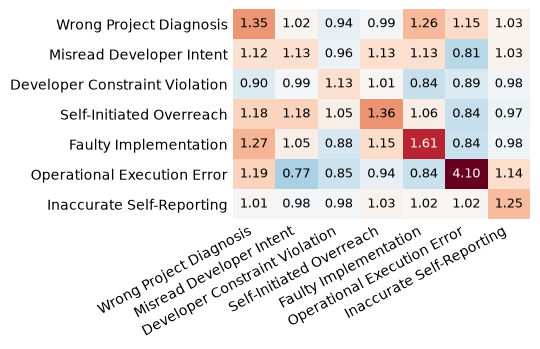

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from table_utils import SYMPTOM_NAMES

ORDER = [f"S{i}" for i in range(1, 8)]


def plot_transition_heatmap(
    transition_lift_conditional, figsize=(5.5, 3.6), vmin=0.7, vmax=2.0
):
    heatmap_data = transition_lift_conditional.pivot(
        index="symptom_t",
        columns="symptom_next",
        values="lift",
    ).loc[ORDER, ORDER]

    data = heatmap_data.to_numpy()
    display_labels = [SYMPTOM_NAMES[s] for s in ORDER]

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)
    cmap = plt.get_cmap("RdBu_r").copy()
    display_data = np.clip(data, vmin, vmax)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(display_data, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(display_labels, rotation=28, ha="right", fontsize=10)
    ax.set_yticklabels(display_labels, fontsize=10)
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            value = data[i, j]
            normed = norm(np.clip(value, vmin, vmax))
            text_color = "white" if (normed < 0.2 or normed > 0.8) else "black"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color,
            )

    fig.tight_layout()
    plt.savefig("results/transition_heatmap.pdf", bbox_inches="tight")
    plt.show()


plot_transition_heatmap(transition_lift_conditional, vmin=0.3, vmax=1.8)

## Session Continuity
We first test adjacent-session persistence using binary session states: whether any misalignment appears in the current session ($\mathrm{any}_t$) and whether any misalignment appears in the next session ($\mathrm{any}_{t+1}$). We report the observed-to-expected association ratio
$$\frac{P(\mathrm{any}_t \cap \mathrm{any}_{t+1})}{P(\mathrm{any}_t)P(\mathrm{any}_{t+1})},$$
the conditional probabilities
$$P(\mathrm{any}_{t+1}=1 \mid \mathrm{any}_t=1), \quad P(\mathrm{any}_{t+1}=1 \mid \mathrm{any}_t=0),$$
and the corresponding risk ratio
$$\frac{P(\mathrm{any}_{t+1}=1 \mid \mathrm{any}_t=1)}{P(\mathrm{any}_{t+1}=1 \mid \mathrm{any}_t=0)}.$$


In [13]:
pairs["any_t"] = (pairs[[f"{s}_t" for s in symptom_cols]].sum(axis=1) > 0).astype(int)
pairs["any_next"] = (pairs[[f"{s}_next" for s in symptom_cols]].sum(axis=1) > 0).astype(
    int
)

count_table = pd.crosstab(pairs["any_t"], pairs["any_next"])
row_pct_table = pd.crosstab(pairs["any_t"], pairs["any_next"], normalize="index")

p_next_given_any = pairs.loc[pairs["any_t"] == 1, "any_next"].mean()
p_next_given_none = pairs.loc[pairs["any_t"] == 0, "any_next"].mean()
risk_ratio = p_next_given_any / p_next_given_none

print(f"P(next=1 | current=1): {p_next_given_any:.3f}")
print(f"P(next=1 | current=0): {p_next_given_none:.3f}")
print(f"Risk ratio: {risk_ratio:.3f}")

p_any_t = pairs["any_t"].mean()
p_any_next = pairs["any_next"].mean()
p_both = ((pairs["any_t"] == 1) & (pairs["any_next"] == 1)).mean()

association_ratio = p_both / (p_any_t * p_any_next)
print(f"Association ratio: {association_ratio:.3f}")

P(next=1 | current=1): 0.519
P(next=1 | current=0): 0.336
Risk ratio: 1.543
Association ratio: 1.259
